
# MultiModal 구현하기

## <span class="mark">목표 : 정형 비정형을 합치자!</span>

## random seed 고정시키기

In [ ]:
import numpy as np
import tensorflow as tf
import random as python_random 
import os

SEED = 42

np.random.seed(SEED)
python_random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['TF_CUDNN_USE_FRONTEND '] = '1'

tf.__version__

## 폴더들 이름정하기
### logs 폴더 이름 정하기

In [ ]:
import os
import os.path as osp
import datetime

now = datetime.datetime.now()
here = "."

logs_folder = osp.join(here, 'logs', f"{now.strftime('%Y%m%d_%H%M%S.%f')}_AAAI24")

os.makedirs(logs_folder)
logs_folder 


### 데이터셋 폴더들 변수 설정

In [ ]:
datasets = {
    "soiling_folder" : "./dataset/preprocessed_20230912/soiling/seg/",
    "cloud_folder" : "./dataset/preprocessed_20230912/cloud/classification/", #./dataset/preprocessed_20230905/cloud/classification/
    "table_folder" : "./dataset/preprocessed_20230912/table/",
}

In [ ]:
options={"option":
            {"fusion method" : "early fusion (all aggregation before input DNN)",
            "created file name": "MultiModal_SolarPowerGenerationForecast-forCloudClassiciation"}
        }

In [ ]:
import yaml

with open(osp.join(logs_folder, 'config.yaml'), 'w') as f:
    yaml.safe_dump(datasets, f, default_flow_style=False)
    yaml.safe_dump(options, f, default_flow_style=False)

## <span class="birk">구름 데이터로 예측하기</span>
- 구름 데이터로 정형 데이터에 들어갈 항목을 예측해보자?

- 구름 이미지를 classification해서 구름 유형을 구해서 정형에 넣기

### classification 결과 불러오기
- error : crop 데이터셋 이름에 panel1이 붙어나옴
- classificationScore.csv

In [ ]:
import pandas as pd 

# 모든 행 출력
# pd.set_option('display.max_rows', None)

c_df = pd.read_csv(f'{datasets["cloud_folder"]}classificationScore.csv')
c_df

In [ ]:
start = 19

for i in range(len(c_df)):
    c_df.loc[i, 'name'] = c_df.loc[i, 'name'][start:start+14]
    
c_df['name']=pd.to_datetime(c_df['name'])
c_df.rename(columns = {'name' :'일시'}, inplace = True)
c_df.drop(columns=["Unnamed: 0", "Unnamed: 0.1"], inplace = True)
c_df

## <span class="birk">오염 데이터로 예측하기</span>
- 오염 데이터로 정형 데이터에 들어갈 항목을 예측해보자?

- 오염 이미지를 seg -> 오염별로 몇퍼 있는지 체크해서 정형에 넣기

### seg 결과 가져오기
"soiling_folder" : "./dataset/preprocessed_20230908/soiling/seg/"


In [ ]:
import pandas as pd 

# 모든 행 출력
# pd.set_option('display.max_rows', None)

s_df = pd.read_csv(f'{datasets["soiling_folder"]}segPercentScore.csv')
s_df

In [ ]:
s_df.drop(columns=["Unnamed: 0"], inplace = True)
s_df['일시']=pd.to_datetime(s_df['일시'])
s_df

## 전처리 : 정형과 비정형을 일대일 매칭하기
### 전처리된 table 가져오기

In [ ]:
import pandas as pd 


df = pd.read_csv(f'{datasets["table_folder"]}weather-addSoilingType_examine_1_upload_preprocessed.csv')
df['일시']=pd.to_datetime(df['일시'])
df.drop(columns=["Unnamed: 0"], inplace = True)
df

### 구름 값 넣기

In [ ]:
df = df.merge(c_df)
df 

### 오염 값 넣기

In [ ]:
df = df.merge(s_df)
df 

### 원래대로 정렬
- 먼저 패널 번호, 그다음에 시간

In [ ]:
df=df.sort_values(by=["panel number","일시"])
df1 = df.reset_index(drop =True)
df1

### Train, test, val split
- train : test : val = 7:2:1

#### Train , test 나누기

In [ ]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(test_size=.2, n_splits=1, random_state = SEED)
train_idxs, test_idxs = next(splitter.split(df1, groups=list(df1['일시'])))

train = df1.iloc[train_idxs]
test = df1.iloc[test_idxs]

#### train, test의 오염비율 확인

In [ ]:
totalsum = len(df1)
soiling_type = ['clean', 'bird_dropping', 'sand', 'plastic_bag', 'shadow', 'pine_pollen']

print('TRAIN', len(df1.loc[train_idxs])/totalsum *100)
print('TEST', len(df1.loc[test_idxs])/totalsum *100)
print('-')
print(len(df1.loc[train_idxs]), len(df1.loc[test_idxs]), len(df1.loc[train_idxs])+len(df1.loc[test_idxs]), totalsum)
print('-')
for s in soiling_type:
    print(f"TRAIN {s} RATIO:", list(df1.loc[train_idxs]['soiling type']).count(s)/len(df1.loc[train_idxs]) *100)
    print(f"TEST {s} RATIO :", list(df1.loc[test_idxs]['soiling type']).count(s)/len(df1.loc[test_idxs]) *100)
    print('-')

#### Train과 Test 겹치는 일시 있는지 확인

In [ ]:
for date_t in train['일시']:
    if date_t in list(test['일시']):
        print(date_t)

#### Train , val 나누기

In [ ]:
totalsum = len(train)

import numpy as np
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(test_size=.125, n_splits=1, random_state = SEED)
train_idxs, val_idxs = next(splitter.split(train, groups=list(train['일시'])))

val = train.iloc[val_idxs]
train = train.iloc[train_idxs]


#### train, val의 오염비율 확인

In [ ]:
soiling_type = ['clean', 'bird_dropping', 'sand', 'plastic_bag', 'shadow', 'pine_pollen']

print('TRAIN', len(df1.loc[train_idxs])/len(df1) *100)
print('VAL', len(df1.loc[val_idxs])/len(df1) *100)
print('-')
print(len(df1.loc[train_idxs]), len(df1.loc[val_idxs]), len(df1.loc[train_idxs])+len(df1.loc[val_idxs]), totalsum)
print('-')
for s in soiling_type:
    print(f"TRAIN {s} RATIO:", list(df1.loc[train_idxs]['soiling type']).count(s)/len(df1.loc[train_idxs]) *100)
    print(f"VAL {s} RATIO :", list(df1.loc[val_idxs]['soiling type']).count(s)/len(df1.loc[val_idxs]) *100)
    print('-')

#### Train과 Val 겹치는 일시 있는지 확인

In [ ]:
for date_t in train['일시']:
    if date_t in list(val['일시']): 
        print(date_t)

In [ ]:
# 모든 행 출력
pd.set_option('display.max_rows', None)

val

In [ ]:
train

In [ ]:
test 

In [ ]:
print(len(train), len(val), len(test), (len(train)+len(val)+len(test)))

#### split 정보 df1에 저장

In [ ]:
type_list = [0 for _ in range(len(df1))]

for i in range(len(df1)):
    if df1.index[i] in train.index :
        type_list[i] = 'train'
    elif df1.index[i] in test.index :
        type_list[i] = 'test'
    elif df1.index[i] in val.index :
        type_list[i] = 'val'

df1['type']= type_list
df1 = df1.sort_values(by=['일시','panel number'])
df1

#### df1 csv로 저장

In [ ]:
# 학슴때 썼던 train, test 포함 csv 저장
df1.to_csv(f"{logs_folder}/df1.csv")

## <span class="birk">정형 데이터로 예측하기</span>
- clean : 패널 4번만 학습



### X, y 나누기

In [ ]:
df1.keys()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

def X_y_split(df1, X_col_list):
    
    X = df1[X_col_list]
    X = X.sort_index()
    
    y = df1['power generation']
    y = y.sort_index() 
    y=pd.DataFrame(y)
    

    x_scaler = MinMaxScaler() #0~1사이의 값으로 정규화해주는 함수
    y_scaler = MinMaxScaler()

    X_norm, y_norm = X.copy(), y.copy()
    X_norm.iloc[:, :] = x_scaler.fit_transform(X_norm.iloc[:, :])
    y_norm.iloc[:, :] = y_scaler.fit_transform(y_norm.iloc[:, :])

    print('X_norm.shape, y_norm.shape : ', X_norm.shape, y_norm.shape)
    
    
    X_train = X_norm.loc[train.index] 
    X_test = X_norm.loc[test.index]
    X_val = X_norm.loc[val.index]
    
    y_train = y_norm.loc[train.index]
    y_test = y_norm.loc[test.index] 
    y_val = y_norm.loc[val.index]
    
    return (X_train, X_test, X_val, y_train, y_test, y_val, y_scaler)

In [ ]:
# X_col_list = []
# for i in df1.keys():
#     if i not in ['일시','power generation','panel number', 'reduction amount(%)', 'soiling type','type']:
#         X_col_list.append(i)
# print('X_col_list ', X_col_list)

In [ ]:
# X = df1[X_col_list]
# X = X.sort_index()
# X  

In [ ]:
# y = df1['power generation']
# y = y.sort_index() 
# y=pd.DataFrame(y)
# y

In [ ]:
# len(y)

### 기온, 풍속, 습도, 일사, 운량 정규화하기

In [ ]:
# from sklearn.preprocessing import MinMaxScaler

# x_scalerT = MinMaxScaler() #0~1사이의 값으로 정규화해주는 함수
# y_scalerT = MinMaxScaler()

# X_norm, y_norm = X.copy(), y.copy()
# X_norm.iloc[:, :] = x_scalerT.fit_transform(X_norm.iloc[:, :])
# y_norm.iloc[:, :] = y_scalerT.fit_transform(y_norm.iloc[:, :])

# X_norm.shape, y_norm.shape

In [ ]:
# X_norm

In [ ]:
# len(list(train.index))

### train, test, val을 이용해  X_trainT, X_testT, X_valT y_trainT, y_testT, y_valT 만들기
#### 기온, 풍속, 습도, 일사, 패널4만 남기기

In [ ]:
# X_trainT = X_norm.loc[train.index] 
# X_trainT

In [ ]:
# X_testT = X_norm.loc[test.index]
# X_testT

In [ ]:
# X_valT = X_norm.loc[val.index] 
# X_valT

In [ ]:
# y_trainT = y_norm.loc[train.index] 
# y_trainT

In [ ]:
# y_testT = y_norm.loc[test.index] 
# y_testT

In [ ]:
# len(y_testT)

In [ ]:
# y_valT = y_norm.loc[val.index] 
# y_valT

### model들

In [ ]:
from keras import models
from keras import layers
from tensorflow.keras import optimizers


def DNN(input_shape): 
    tf.keras.backend.clear_session()
    initializer = tf.keras.initializers.GlorotUniform(seed=SEED)
    
    model = models.Sequential()
    model.add(layers.Dense(64, activation='relu',
                           input_shape=(input_shape[1],), kernel_initializer=initializer))
    model.add(layers.Dense(64, activation='relu', kernel_initializer=initializer))
    model.add(layers.Dense(1, activation = 'sigmoid', kernel_initializer=initializer))
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model

In [ ]:
from tensorflow.keras import optimizers

def CNN(input_shape):
    initializer = tf.keras.initializers.GlorotUniform(seed=SEED)

    model = models.Sequential()
    model.add(layers.Conv1D(64, 3,  activation="relu", 
                            input_shape=(input_shape[1],1), kernel_initializer = initializer)) 
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Flatten())
    model.add(layers.Dense(100, activation = 'relu', kernel_initializer = initializer))
    model.add(layers.Dense(1, activation = 'sigmoid', kernel_initializer = initializer))

    Adam = optimizers.Adam(beta_1=0.9, beta_2=0.999, epsilon=None, amsgrad=False)

    model.compile(loss = 'mse', optimizer=optimizers.experimental.Adadelta(), metrics=['mae'])

    return model

In [ ]:
# from keras import models
# from keras import layers
# from keras import losses
# from tensorflow.keras import optimizers

# def CNN(): #동일한 모델을 여러 번 생성할 것이므로 함수를 만들어 사용합니다.
#     model = models.Sequential([
# #           layers.Rescaling(1./255),
# #           layers.RandomFlip("horizontal_and_vertical"),
#           layers.Conv2D(16, 3, padding='same', activation='relu'),
#           layers.MaxPooling2D(),
#           layers.Conv2D(32, 3, padding='same', activation='relu'),
#           layers.MaxPooling2D(),
#           layers.Conv2D(64, 3, padding='same', activation='relu'),
#           layers.MaxPooling2D(),
#           layers.Conv2D(128, 3, padding='same', activation='relu'),
#           layers.MaxPooling2D(),
#           layers.Conv2D(256, 3, padding='same', activation='relu'),
#           layers.MaxPooling2D(),
#           layers.Flatten(),
#           layers.Dense(128, activation='relu'),
#           layers.Dense(128, activation='relu'),
#           layers.Dense(64, activation='relu'),
#           layers.Dense(1)
#         ])
#     model.compile(optimizer=optimizers.experimental.Adadelta(), loss=losses.MeanSquaredError(), metrics=['mae'])
#     return model

### train
#### k-겹 교차검증? 
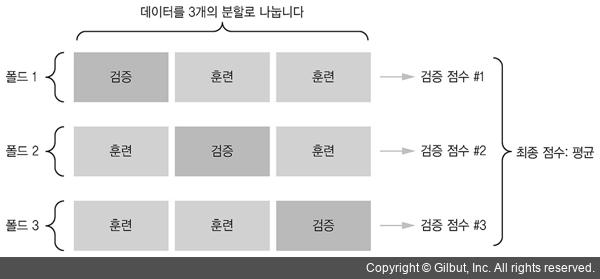
- https://tensorflow.blog/%EC%BC%80%EB%9D%BC%EC%8A%A4-%EB%94%A5%EB%9F%AC%EB%8B%9D/3-6-%EC%A3%BC%ED%83%9D-%EA%B0%80%EA%B2%A9-%EC%98%88%EC%B8%A1-%ED%9A%8C%EA%B7%80-%EB%AC%B8%EC%A0%9C/

--> 우선 안쓰긴했는데 나중에 쓸수도..?

In [ ]:
from itertools import *
dataset = {'weather':
           ['기온(°C)','풍속(m/s)','습도(%)','일사(MJ/m^2)',],
           'soiling':
           ['panel','bird dropping','pine pollen','plastic bag','sand','shadow'],
           'sunlight':
           ['A-sky','B-pattern','C-thick-dark','D-thick-white','E-veil']
          }


X_col_dic = {}
for i in range(1,4):
    print(list(combinations(dataset.keys(), i)))
    
    for com in list(combinations(dataset.keys(), i)):
        columns = [] 
        for c in com:
            columns += dataset[c]
        X_col_dic["_".join(com)] = columns


In [ ]:
X_col_dic

In [ ]:
import numpy as np
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint
from pickle import dump

  
num_epochs= 1000


model_names= ["DNN"] #CNN

historys = {}
models_dic = {}
scalers ={}

for model_name in model_names :  
    historys[model_name]={}
    models_dic[model_name]={}
    
    for combi_name, X_col_list in X_col_dic.items() : 
        print(">>>>>>>>>>")
        print(f"model : {model_name}, combi name : {combi_name}, X_col_list : {X_col_list}")
        
        (X_train, X_test, X_val, y_train, y_test, y_val, y_scaler) =X_y_split(df1.copy(), X_col_list)
        
        os.makedirs(osp.join(logs_folder,model_name,combi_name), exist_ok= True)
        
        X_test.to_csv(f"{logs_folder}/{model_name}/{combi_name}/X_test.csv")
        y_test.to_csv(f"{logs_folder}/{model_name}/{combi_name}/y_test.csv")
        
        dump(y_scaler, open(f"{logs_folder}/{model_name}/{combi_name}/y_scaler.pkl", 'wb'))


        es = EarlyStopping(monitor='val_loss', patience=10)
        best_check = ModelCheckpoint(filepath=f"{logs_folder}/{model_name}/{combi_name}/best_model.h5", 
                                     monitor="val_loss",
                                     save_best_only=True,
                                     save_weights_only=False,
                                    )
        
        print("X_train.shape :", X_train.shape)
        
        if model_name =="DNN" :
            model = DNN(X_train.shape)
        if model_name =="CNN" :
            model = CNN(X_train.shape)
        model.summary()

        historys[model_name][combi_name]= model.fit(X_train, y_train, 
                                                    epochs=num_epochs, batch_size=4,
                                                    validation_data = (X_val, y_val),
                                                    verbose =1, callbacks=[es, best_check])
#         models_dic[model_name][combi_name] = model

In [ ]:
historys["DNN"].keys()

### learning curve

In [ ]:
historys["DNN"].keys()

In [ ]:
import matplotlib.pyplot as plt

for model_name in historys.keys():
    for combi_name in historys[model_name].keys():
        #train
        mae = historys[model_name][combi_name].history['mae']
        loss = historys[model_name][combi_name].history['loss']

        #val
        val_mae = historys[model_name][combi_name].history['val_mae']
        val_loss = historys[model_name][combi_name].history['val_loss']
        
        
        
        #graph 
        plt.figure(figsize=(8, 8))
        plt.subplot(2, 1, 1)
        plt.plot(mae, label='Training MAE')
        plt.plot(val_mae, label='Validation MAE')
        plt.legend(loc='lower right')
        plt.ylabel('MAE')
        plt.ylim([0,0.3])
        plt.title(f'Training and Validation MAE\nUsed Dataset : {combi_name}')

        plt.subplot(2, 1, 2)
        plt.plot(loss, label='Training Loss')
        plt.plot(val_loss, label='Validation Loss')
        plt.legend(loc='upper right')
        plt.ylabel('MSE')
        plt.ylim([0,0.3])
        plt.title(f'Training and Validation Loss\nUsed Dataset : {combi_name}')
        plt.xlabel('epoch')
        
        plt.tight_layout() 
        
        plt.savefig(f'{logs_folder}/{model_name}/{combi_name}/learning_curve.png', facecolor='#eeeeee') 
        
        plt.show()

In [ ]:
# #train
# mae = historyT.history['mae']
# loss = historyT.history['loss']

# #val
# val_mae = historyT.history['val_mae']
# val_loss = historyT.history['val_loss']

In [ ]:
# import matplotlib.pyplot as plt

# #graph 
# plt.figure(figsize=(8, 8))
# plt.subplot(2, 1, 1)
# plt.plot(mae, label='Training MAE')
# plt.plot(val_mae, label='Validation MAE')
# plt.legend(loc='lower right')
# plt.ylabel('MAE')
# plt.ylim([min(plt.ylim()),max(plt.ylim())])
# plt.title('Training and Validation MAE')

# plt.subplot(2, 1, 2)
# plt.plot(loss, label='Training Loss')
# plt.plot(val_loss, label='Validation Loss')
# plt.legend(loc='upper right')
# plt.ylabel('MSE')
# plt.ylim([0,0.2])
# plt.title('Training and Validation Loss')
# plt.xlabel('epoch')
# plt.show()

### evaluate

In [ ]:
from sklearn.metrics import r2_score #R^2
from sklearn.metrics import mean_squared_error #MSE
from sklearn.metrics import mean_absolute_error #MAE

def evaluate(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    MSE = mean_squared_error(y_true, y_pred) 
    rmse = np.sqrt(MSE)
    mae = mean_absolute_error(y_true, y_pred)
    return np.round(r2*100, 10), np.round(rmse, 10), np.round(mae, 10)

In [ ]:
from pickle import load


f_summary = open(f"{logs_folder}/result_summary.txt","w+")
results = {}


for model_name in historys.keys():
    f_summary.write("----------------\n")
    f_summary.write(f"model name : {model_name}\n\n\n")
    results[model_name] = {}
    for combi_name in historys[model_name].keys():
        results[model_name][combi_name] = {}
        # 저장했던거 불러오기
        X_test = pd.read_csv(f"{logs_folder}/{model_name}/{combi_name}/X_test.csv", index_col=0)
        y_test = pd.read_csv(f"{logs_folder}/{model_name}/{combi_name}/y_test.csv", index_col=0)

        model = models.load_model(f"{logs_folder}/{model_name}/{combi_name}/best_model.h5")
        scaler = load(open(f"{logs_folder}/{model_name}/{combi_name}/y_scaler.pkl", 'rb'))
        
        y_test_inv = y_scaler.inverse_transform(y_test)

        y_forecast = model.predict(X_test)
        y_forecast_inv = y_scaler.inverse_transform(y_forecast)
        y_forecast_inv = y_forecast_inv.clip(min=0)

        r2, rmse, mae = evaluate(y_test_inv, y_forecast_inv)
        
        print("----------------")
        print(f"model name : {model_name}\ncombi name : {combi_name}\n R2: {r2}, RMSE: {rmse}, MAE: {mae}")
        print("----------------")
        
        results[model_name][combi_name]["r2"] = r2
        results[model_name][combi_name]["rmse"] = rmse
        results[model_name][combi_name]["mae"] = mae
        
        f= open(f"{logs_folder}/{model_name}/{combi_name}/result.txt","w+")
        f.write(f"model name : {model_name}\ncombi name : {combi_name}\n R2: {r2}, RMSE: {rmse}, MAE: {mae}")
        f.close()
        
        f_summary.write(f"combi name : {combi_name}\n\t R2: {r2}, RMSE: {rmse}, MAE: {mae}\n\n")

f_summary.close()
        
        

In [ ]:


# y_testT_inv = y_scalerT.inverse_transform(y_testT)

# y_forecastT = modelT.predict(X_testT)
# y_forecastT_inv = y_scalerT.inverse_transform(y_forecastT)
# y_forecastT_inv = y_forecastT_inv.clip(min=0)

# r2, rmse, mae = evaluate(y_testT_inv, y_forecastT_inv)

# print(f"nn, R2: {r2}, RMSE: {rmse}, MAE: {mae}")

## Result



In [ ]:
# result = {
#     'table': 
#     {'ifClean':'-', 'ifDirty':'-'},
#     'soiling': '-',
#     'fusion': '-',
# }

### Test structured data model

- 학습데이터 : 패널 4번
- 실제로 패널이 깨끗할 경우(패널 4번)과 실제는 패널이 더러울 경우(패널 1번)과 같이 비교

In [ ]:
cmap = ["dodgerblue","dodgerblue","dodgerblue","orange"]

In [ ]:
import matplotlib.pyplot as plt

for model_name in historys.keys():
    for combi_name in historys[model_name].keys():

        X_test = pd.read_csv(f"{logs_folder}/{model_name}/{combi_name}/X_test.csv", index_col=0)
        y_test = pd.read_csv(f"{logs_folder}/{model_name}/{combi_name}/y_test.csv", index_col=0)
        
        xi = range(len(y_test.index))
        
        model = models.load_model(f"{logs_folder}/{model_name}/{combi_name}/best_model.h5")
        scaler = load(open(f"{logs_folder}/{model_name}/{combi_name}/y_scaler.pkl", 'rb'))
        
        y_test_inv = y_scaler.inverse_transform(y_test)

        y_forecast = model.predict(X_test)
        y_forecast_inv = y_scaler.inverse_transform(y_forecast)
        y_forecast_inv = y_forecast_inv.clip(min=0)
        
        
        r2, rmse, mae = results[model_name][combi_name]["r2"], results[model_name][combi_name]["rmse"],results[model_name][combi_name]["mae"]
        
        # 그래프 그리기 ---
        
        plt.figure(figsize=(15, 5))
        plt.bar(xi, y_test_inv.flatten(), label= 'Actual', color="dodgerblue", width=1, alpha=0.8)
        plt.scatter(xi, y_forecast_inv, label='Forecast', color='black', s=2, marker='s')
        
        plt.legend(loc="lower right", ncol= 1, bbox_to_anchor=(1.110, 0.5))
        
        
        #f"Forecasted Solar Power Generation Result\n\nModel : {model_name} / Used Dataset : {combi_name}\nR2: {r2}, RMSE: {rmse}, MAE: {mae}"
        plt.title(f"Forecasted Solar Power Generation Result\n\nUsed Dataset : {combi_name}\nR2: {r2}, RMSE: {rmse}, MAE: {mae}")
        plt.ylabel('solar power generation')
        plt.xlabel('Test index number')
        plt.grid(visible=True, linestyle='--',  axis='y')
#         plt.vlines(v_point, 0, 999, color='red', linestyle='--', linewidth=3)
        plt.margins(x=0.005) 
        
        plt.savefig(f'{logs_folder}/{model_name}/{combi_name}/result.png', facecolor='#eeeeee')
        #---
        
        colors=[]
        for i in X_test.index:
            if i in test.index:
                cmap_i = int(test.loc[i]["panel number"])
                colors.append(cmap[cmap_i-1])
        
        r2, rmse, mae = results[model_name][combi_name]["r2"], results[model_name][combi_name]["rmse"],results[model_name][combi_name]["mae"]
        
        plt.figure(figsize=(15, 5))
        plt.bar(xi, y_test_inv.flatten(), label= 'Actual', color=colors, width=1, alpha=0.8)
        plt.scatter(xi, y_forecast_inv, label='Forecast', color='black', s=2, marker='s')
        
        plt.legend(loc="lower right", ncol= 1, bbox_to_anchor=(1.110, 0.5))
        
        
        #f"Forecasted Solar Power Generation Result\n\nModel : {model_name} / Used Dataset : {combi_name}\nR2: {r2}, RMSE: {rmse}, MAE: {mae}"
        plt.title(f"Forecasted Solar Power Generation Result\n\nUsed Dataset : {combi_name}\nR2: {r2}, RMSE: {rmse}, MAE: {mae}")
        plt.ylabel('solar power generation')
        plt.xlabel('Test index number')
        plt.grid(visible=True, linestyle='--',  axis='y')
#         plt.vlines(v_point, 0, 999, color='red', linestyle='--', linewidth=3)
        plt.margins(x=0.005) 

        plt.savefig(f'{logs_folder}/{model_name}/{combi_name}/result_split_clean.png', facecolor='#eeeeee')
        

In [ ]:
# import matplotlib.pyplot as plt
# %matplotlib inline


# plt.figure(figsize=(15, 10))
# xt = list(range(len(y_testT.index)))
# xs = list(range(len(y_testS.index)))


# r2, rmse, mae = evaluate(y_testT_inv, y_forecastT_inv)
# print(f"[clean panel일 경우] R2: {r2}, RMSE: {rmse}, MAE: {mae}")
# result['table']['ifClean'] = {"R2": str(r2), "RMSE": str(rmse), "MAE": str(mae)}

# plt.subplot(211)
# plt.bar(xt,y_testT_inv.flatten(), label= '(Clean)panel4 pow_gen', color='limegreen')
# plt.scatter(xt, y_forecastT_inv.flatten(), label='forecast', color='black', alpha=0.7)
# plt.legend(loc=(1.0, 0))
# plt.title(f"Test structured data(weather) If Clean panel\nR2: {r2}, RMSE: {rmse}, MAE: {mae}")
# plt.ylabel('solar power generation')
# plt.xlabel('test index number')
# plt.grid(visible=True, linestyle='--',  axis='y')
# plt.margins(x=0.01) 


# r2, rmse, mae = evaluate(gt, y_forcastT_inv_F)
# print(f"[dirty panel일 경우] R2: {r2}, RMSE: {rmse}, MAE: {mae}")
# result['table']['ifDirty'] = {"R2": str(r2), "RMSE": str(rmse), "MAE": str(mae)}

# plt.subplot(212)
# plt.bar(xs, gt, label= '(Dirty)panel1 pow_gen', color = 'hotpink')
# plt.scatter(xs, y_forcastT_inv_F, label='forecast', color='black', alpha=0.7)
# plt.legend(loc=(1.0, 0))
# plt.title(f"Test structured data(weather) If Dirty panel\nR2: {r2}, RMSE: {rmse}, MAE: {mae}")
# plt.ylabel('solar power generation')
# plt.xlabel('test index number')
# plt.grid(visible=True, linestyle='--',  axis='y')
# plt.margins(x=0.01) 

# plt.tight_layout()
# plt.savefig(f'{logs_folder}/result_table.png') 

In [ ]:
# import matplotlib.pyplot as plt
# %matplotlib inline


# plt.figure(figsize=(15, 10))
# xt = list(range(len(y_testT.index)))
# xs = list(range(len(y_testS.index)))


# r2, rmse, mae = evaluate(y_testT_inv, y_forecastT_inv)

# plt.subplot(211)
# plt.bar(xt,y_testT_inv.flatten(), label= '(Clean)panel4 pow_gen', color='mediumseagreen', width=1.0, edgecolor='black')
# plt.bar(xt, y_forecastT_inv.flatten(), label='forecast', color='crimson', alpha=0.5, width=1.0, edgecolor='black')
# plt.legend(loc=(1.0, 0))
# plt.title(f"Test structured data(weather) If Clean panel\nR2: {r2}, RMSE: {rmse}, MAE: {mae}")
# plt.ylabel('solar power generation')
# plt.xlabel('test index number')
# plt.grid(visible=True, linestyle='--',  axis='y')
# plt.margins(x=0.01) 


# r2, rmse, mae = evaluate(gt, y_forcastT_inv_F)

# plt.subplot(212)
# plt.bar(xs, gt, label= '(Dirty)panel1 pow_gen', color = 'limegreen', width=1.0, edgecolor='black')
# plt.bar(xs, y_forcastT_inv_F.flatten(), label='forecast', color='crimson', alpha=0.5, width=1.0, edgecolor='black')
# plt.legend(loc=(1.0, 0))
# plt.title(f"Test structured data(weather) If Dirty panel\nR2: {r2}, RMSE: {rmse}, MAE: {mae}")
# plt.ylabel('solar power generation')
# plt.xlabel('test index number')
# plt.grid(visible=True, linestyle='--',  axis='y')
# plt.margins(x=0.01) 

# plt.tight_layout()
# plt.savefig(f'{logs_folder}/result_table.png') 

- 패널이 깨끗했을 때는 예측이 그럭저럭 잘 되지만, 패널에 오염이 쌓였을 경우 엉망이된다.

### Test unstructured data model
- 패널위 오염 이미지를 보고 발전감소량을 예측하자

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

r2, rmse, mae = evaluate(y_testS_inv, y_forecastS_inv)
print(f"R2: {r2}, RMSE: {rmse}, MAE: {mae}")

plt.figure(figsize=(15, 5))

plt.bar(xs, y_testS_inv.flatten(), label= 'Actual\n power generation reduction\n percentage', color='dodgerblue')
plt.scatter(xs, y_forecastS_inv, label='forecast', color='black', alpha=0.7)
plt.legend(loc=(1.0, 0))
plt.title(f"Test unstructured data(panel Image)\nR2: {r2}, RMSE: {rmse}, MAE: {mae}")
plt.ylabel('solar power generation reduction percentage')
plt.xlabel('test index number')
plt.grid(visible=True, linestyle='--',  axis='y')
plt.margins(x=0.01) 



result['soiling'] = {"R2": str(r2), "RMSE": str(rmse), "MAE": str(mae)}
plt.savefig(f'{logs_folder}/result_soiling.png') 

In [ ]:
# import matplotlib.pyplot as plt
# %matplotlib inline

# r2, rmse, mae = evaluate(y_testS_inv, y_forecastS_inv)
# print(f"R2: {r2}, RMSE: {rmse}, MAE: {mae}")

# plt.figure(figsize=(15, 5))

# plt.bar(xs, y_testS_inv.flatten(), label= 'Actual\n power generation reduction\n percentage', color='dodgerblue', width=1.0, edgecolor='black')
# plt.bar(xs, y_forecastS_inv.flatten(), label='forecast', color='crimson', alpha=0.5, width=1.0)
# plt.legend(loc=(1.0, 0))
# plt.title(f"Test unstructured data(panel Image)\nR2: {r2}, RMSE: {rmse}, MAE: {mae}")
# plt.ylabel('solar power generation reduction percentage')
# plt.xlabel('test index number')
# plt.grid(visible=True, linestyle='--',  axis='y')
# plt.margins(x=0.01) 

In [ ]:
test.loc[y_testS.index][test['soiling type']=='shadow']

In [ ]:
y_resultS = y_testS
y_resultS['y_testS_inv'] = y_testS_inv
y_resultS['y_forecastS_inv'] = y_forecastS_inv
y_resultS

In [ ]:
y_testS_inv

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

soiling_type = list(test['soiling type'].unique())
soiling_type.remove('clean')
print(soiling_type)

for s in soiling_type:
    
    idxs = test.loc[y_testS.index][test['soiling type']== s ].index
    x = list(range(len(y_resultS['y_testS_inv'].loc[idxs])))
    
    r2, rmse, mae = evaluate(np.array(y_resultS['y_testS_inv'].loc[idxs]), np.array(y_resultS['y_forecastS_inv'].loc[idxs]))
    result['soiling'][s] = {"R2": str(r2), "RMSE": str(rmse), "MAE": str(mae)}

    plt.figure(figsize=(15, 5))
    
    plt.bar(x, y_resultS['y_testS_inv'].loc[idxs], label= 'Actual\n power generation reduction\n percentage', color='dodgerblue')
    plt.scatter(x, y_resultS['y_forecastS_inv'].loc[idxs], label='forecast', color='black', alpha=0.7)
#     plt.legend(loc=(1.0, 0))
    plt.title(f"Test unstructured data(panel Image)\nsoiling : {s} ({len(x)})\nR2: {r2}, RMSE: {rmse}, MAE: {mae}")
    plt.ylabel('solar power generation reduction percentage')
    plt.xlabel('test index number')
    plt.grid(visible=True, linestyle='--',  axis='y')
    plt.margins(x=0.01) 


    
    plt.savefig(f'{logs_folder}/result_soiling_{s}.png') 
#     print(np.array(y_resultS['y_testS_inv'].loc[idxs]))
#     print(np.array(y_resultS['y_forecastS_inv'].loc[idxs]))
#     break

In [ ]:
# import matplotlib.pyplot as plt
# %matplotlib inline

# soiling_type = list(test['soiling type'].unique())
# soiling_type.remove('clean')
# print(soiling_type)

# for s in soiling_type:
    
#     idxs = test.loc[y_testS.index][test['soiling type']== s ].index
#     x = list(range(len(y_resultS['y_testS_inv'].loc[idxs])))
    
#     r2, rmse, mae = evaluate(np.array(y_resultS['y_testS_inv'].loc[idxs]), np.array(y_resultS['y_forecastS_inv'].loc[idxs]))

#     plt.figure(figsize=(15, 5))
    
#     plt.bar(x, y_resultS['y_testS_inv'].loc[idxs], label= 'Actual\n power generation reduction\n percentage', color='dodgerblue', width=1.0, edgecolor='black' )
#     plt.bar(x, y_resultS['y_forecastS_inv'].loc[idxs], label='forecast', color='darkorange', alpha=0.5, width=1.0)
# #     plt.legend(loc=(1.0, 0))
#     plt.title(f"Test unstructured data(panel Image)\nsoiling : {s} ({len(x)})\nR2: {r2}, RMSE: {rmse}, MAE: {mae}")
#     plt.ylabel('solar power generation reduction percentage')
#     plt.xlabel('test index number')
#     plt.grid(visible=True, linestyle='--',  axis='y')
#     plt.margins(x=0.01) 


    
#     plt.savefig(f'{logs_folder}/result_soiling_{s}.png') 

- 패널 위 오염에 대해 발전감소량을 예측하는 모델이 성능이 좋지않다 --> 데이터셋을 어떻게 나누느냐에 따라 달라진다.


### Test Fusion model

- 발전량 예측에 발전감소량을 추가계산해서 오염된 패널의 발전량을 구하자

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline


r2, rmse, mae = evaluate(gt, y_forecastF_inv)
print(f"R2: {r2}, RMSE: {rmse}, MAE: {mae}")
result['fusion'] = {"R2": str(r2), "RMSE": str(rmse), "MAE": str(mae)}

plt.figure(figsize=(15, 5))
x = list(range(len(y_testS.index)))

plt.bar(x, gt, label= '(dirty)solar power generation', color='mediumslateblue')
plt.scatter(x, y_forecastF_inv, label='forecast', color='black', alpha=0.7)
plt.legend(loc=(1.0, 0))
plt.title(f"Fusion\nR2: {r2}, RMSE: {rmse}, MAE: {mae}")
plt.ylabel('solar power generation reduction percentage')
plt.xlabel('test index number')
plt.grid(visible=True, linestyle='--',  axis='y')
plt.margins(x=0.01) 


plt.savefig(f'{logs_folder}/result_fusion.png') 

In [ ]:
# import matplotlib.pyplot as plt
# %matplotlib inline


# r2, rmse, mae = evaluate(gt, y_forecastF_inv)

# plt.figure(figsize=(15, 5))
# x = list(range(len(y_testS.index)))

# plt.bar(x, gt, label= '(dirty)solar power generation', color='mediumslateblue', width=1.0, edgecolor='black' )
# plt.bar(x, y_forecastF_inv.flatten(), label='forecast', color='darkorange', alpha=0.5, width=1.0)
# # plt.fill_between(x,gt, y_forecastF_inv.flatten(),interpolate=True, alpha = 0.25)
# plt.legend(loc=(1.0, 0))
# plt.title(f"Fusion\nR2: {r2}, RMSE: {rmse}, MAE: {mae}")
# plt.ylabel('solar power generation reduction percentage')
# plt.xlabel('test index number')
# plt.grid(visible=True, linestyle='--',  axis='y')
# plt.margins(x=0.01) 

### 결과 저장하기

In [ ]:
result 

In [ ]:
import yaml

with open(osp.join(logs_folder, 'result.yaml'), 'w') as f:
    yaml.safe_dump(result, f, default_flow_style=False)